In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('dataset.csv')

In [4]:
df.head()

,HouseSize,DistanceToCity,Location,Price
0,NaN,22.92,B,20.74
1,48.6,27.90,B,19.35
2,NaN,28.29,A,23.30
3,65.2,25.99,A,25.37
4,47.7,29.19,A,19.66


In [6]:
df.shape

(100, 4)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   HouseSize       95 non-null     float64
 1   DistanceToCity  95 non-null     float64
 2   Location        100 non-null    str    
 3   Price           100 non-null    float64
dtypes: float64(3), str(1)
memory usage: 3.3 KB


In [9]:
df.columns

Index(['HouseSize', 'DistanceToCity', 'Location', 'Price'], dtype='str')

In [10]:
df.isnull().sum()

HouseSize         5
DistanceToCity    5
Location          0
Price             0
dtype: int64

In [12]:
df.describe()

,HouseSize,DistanceToCity,Price
count,95.000000,95.000000,100.000000
mean,53.026316,32.570421,22.250000
std,19.867916,11.910253,6.993549
min,23.800000,20.410000,13.510000
25%,44.200000,26.035000,19.167500
50%,49.300000,30.870000,20.450000
75%,56.750000,33.425000,23.320000
max,133.000000,81.930000,52.660000


<Axes: xlabel='HouseSize', ylabel='Count'>

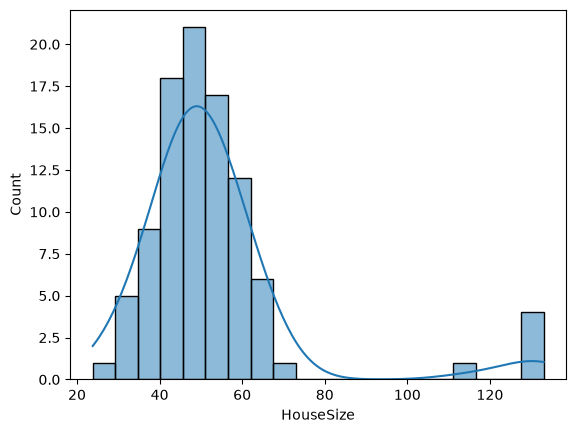

In [14]:
sns.histplot(df['HouseSize'],kde=True)

<Axes: xlabel='Price', ylabel='Count'>

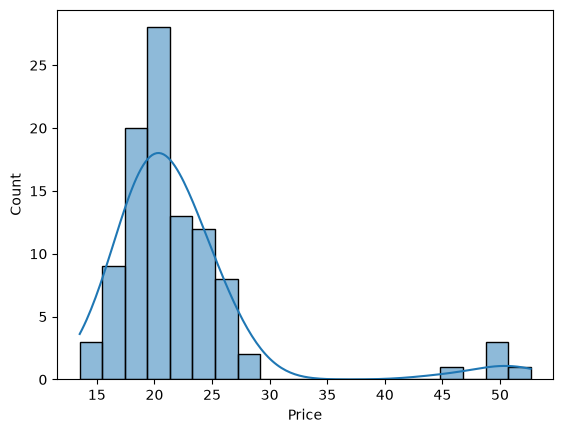

In [17]:
sns.histplot(df['Price'],kde=True)

<Axes: xlabel='DistanceToCity', ylabel='Count'>

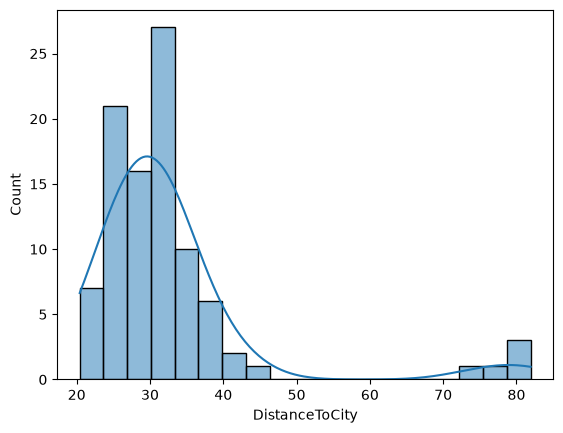

In [18]:
sns.histplot(df['DistanceToCity'],kde=True)

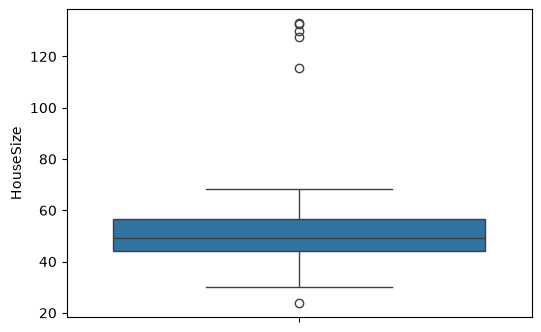

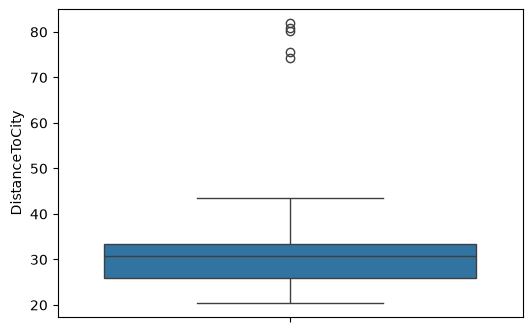

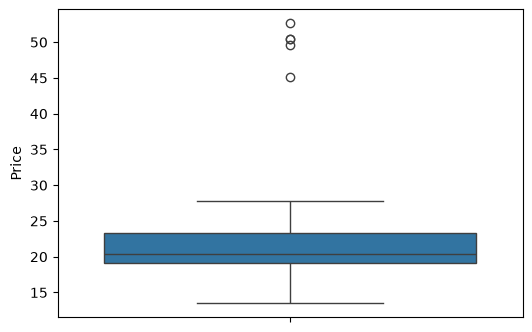

In [26]:
numerical_column = ['HouseSize', 'DistanceToCity', 'Price']
for col in numerical_column:
        plt.figure(figsize=(6,4))
        sns.boxplot(df[col])

In [29]:
for col in numerical_column:
    Q1= df[col].quantile(0.25)
    Q3= df[col].quantile(0.75)

    IQR = Q3-Q1
    lowwer = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lowwer) | (df[col] > upper)]

    print(f"{col}")
    print(f"Lowwer Bound {lowwer}")
    print(f"Upper Bound {upper}")
    print(f"No of Outliers {len(outliers)}")
    print(outliers[col])

HouseSize
Lowwer Bound 25.375000000000007
Upper Bound 75.57499999999999
No of Outliers 6
74     23.8
95    115.4
96    133.0
97    132.6
98    130.1
99    127.7
Name: HouseSize, dtype: float64
DistanceToCity
Lowwer Bound 14.949999999999996
Upper Bound 44.51
No of Outliers 5
95    81.93
96    75.58
97    80.77
98    80.29
99    74.29
Name: DistanceToCity, dtype: float64
Price
Lowwer Bound 12.93875
Upper Bound 29.54875
No of Outliers 5
95    45.12
96    50.43
97    50.44
98    52.66
99    49.62
Name: Price, dtype: float64


    The IQR method identifies 6 potential outliers in HouseSize, 5 in DistanceToCity, and 5 in Price. The five extreme observations occur across all three variables, suggesting they may represent a genuine segment of the data rather than errors.

In [30]:
df.loc[[95,96,97,98,99]]

,HouseSize,DistanceToCity,Location,Price
95,115.4,81.93,C,45.12
96,133.0,75.58,C,50.43
97,132.6,80.77,B,50.44
98,130.1,80.29,C,52.66
99,127.7,74.29,A,49.62


In [31]:
df[df['HouseSize'].isna() | df['DistanceToCity'].isna()] 

,HouseSize,DistanceToCity,Location,Price
0,NaN,22.92,B,20.74
2,NaN,28.29,A,23.30
24,44.6,NaN,C,19.28
38,NaN,34.07,B,18.36
60,NaN,25.13,B,17.04
61,48.1,NaN,B,20.39
62,38.9,NaN,C,19.23
71,NaN,25.92,A,25.07
76,50.9,NaN,A,21.02
91,59.7,NaN,C,24.41


In [33]:
df.groupby('Location')[['HouseSize','DistanceToCity']].median()

,HouseSize,DistanceToCity
Location,,
A,49.90,31.115
B,48.35,29.620
C,51.75,31.300


In [35]:
df.HouseSize = df['HouseSize'].fillna(df.groupby('Location')['HouseSize'].transform('median'))

In [36]:
df

,HouseSize,DistanceToCity,Location,Price
0,48.35,22.92,B,20.74
1,48.60,27.90,B,19.35
2,49.90,28.29,A,23.30
3,65.20,25.99,A,25.37
4,47.70,29.19,A,19.66
...,...,...,...,...
95,115.40,81.93,C,45.12
96,133.00,75.58,C,50.43
97,132.60,80.77,B,50.44
98,130.10,80.29,C,52.66


In [37]:
df.DistanceToCity = df['DistanceToCity'].fillna(df.groupby('Location')['DistanceToCity'].transform('median'))

In [39]:
df.isna().sum()

HouseSize         0
DistanceToCity    0
Location          0
Price             0
dtype: int64

In [40]:
X = df.drop('Price',axis=1)
y = df['Price']

In [42]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [43]:
X_train.shape,X_test.shape

((80, 3), (20, 3))

In [46]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore',sparse_output=False)
location_train= encoder.fit_transform(X_train[['Location']])
location_test= encoder.fit_transform(X_test[['Location']])

In [48]:
X_train_numeric = X_train[['HouseSize','DistanceToCity']]
X_test_numeric = X_test[['HouseSize','DistanceToCity']]

In [49]:
X_train_Final = np.hstack([X_train_numeric,location_train])
X_test_Final = np.hstack([X_test_numeric,location_test])

In [51]:
X_train_Final.shape,X_test_Final.shape

((80, 5), (20, 5))

In [52]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_Final,y_train)
y_pred = model.predict(X_test_Final)

In [53]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test,y_pred)
print("MAE : ",mae)

MAE :  1.0442711800588076


In [ ]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print("R²:", r2)

R²: 0.7392328243843438


In [ ]:
from sklearn.metrics import mean_squared_error
rmse = mean_squared_error(y_test, y_pred) ** 0.5
print("RMSE:", rmse)

RMSE: 1.2206581957428824


In [56]:
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

comparison

,Actual Price,Predicted Price
0,20.17,19.611496
1,23.43,23.395612
2,19.75,21.563227
3,17.75,19.161710
4,18.50,16.814988
5,20.18,20.898568
6,23.11,21.887018
7,19.38,21.081739
8,19.62,18.768331
9,20.74,19.692203
